In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
arquivo = files.upload()

Saving img.jpg to img.jpg


array([[ 76, 101, 131, ..., 157, 157, 157],
       [ 49,  75, 105, ..., 157, 157, 157],
       [ 31,  54,  80, ..., 157, 157, 157],
       ...,
       [ 71,  71,  71, ...,  59,  59,  59],
       [ 76,  76,  77, ...,  59,  59,  59],
       [ 79,  80,  80, ...,  59,  59,  59]], dtype=uint8)
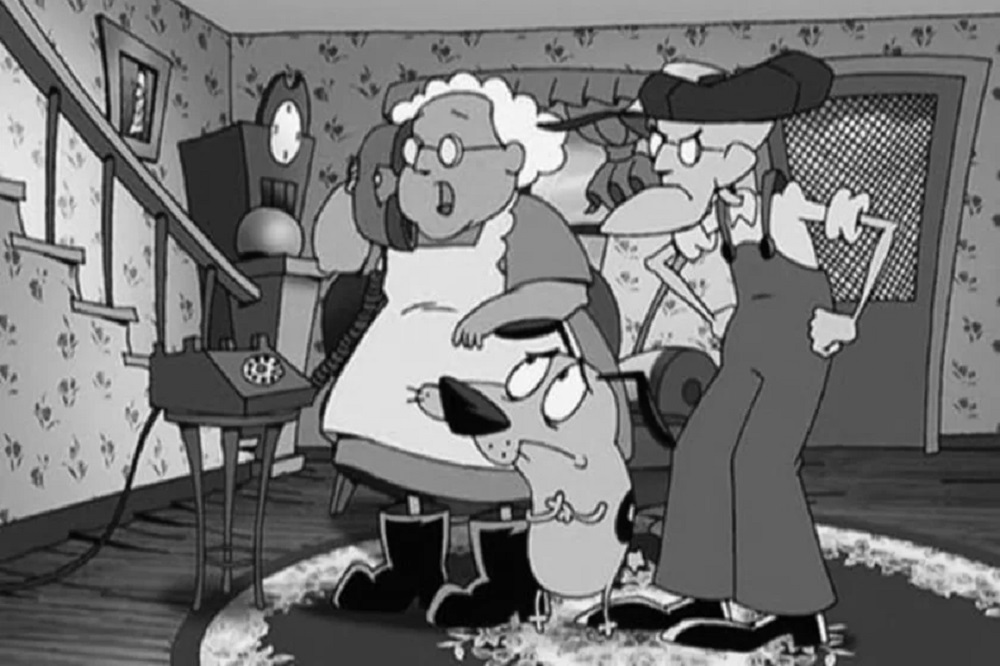

In [ ]:
img_bgr = cv2.imread('img.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray

In [ ]:
altura = img_gray.shape[0]
largura = img_gray.shape[1]

img_gray.shape

(666, 1000)

Translação de exclusão

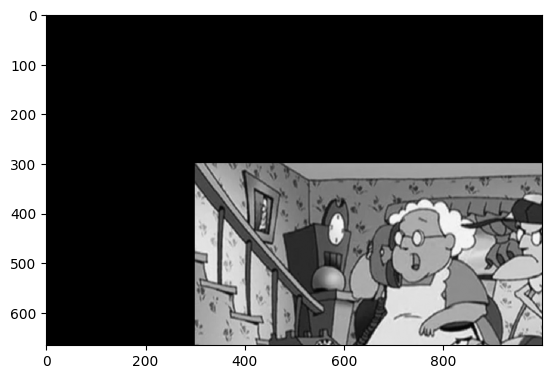

In [ ]:
dx = 300
dy = 300

transladada = np.zeros((altura, largura), dtype=np.uint8)

for x in range(largura):
    for y in range(altura):
        novo_X = x + dx
        novo_Y = y + dy

        if novo_X >= 0 and novo_X < largura and novo_Y >= 0 and novo_Y < altura:
            transladada[novo_Y, novo_X] = img_gray[y, x]

plt.imshow(transladada, cmap='gray')
plt.show()

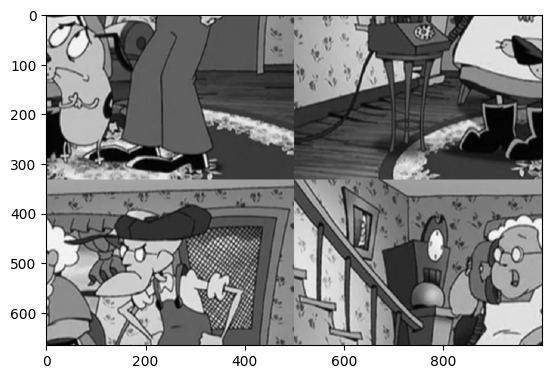

In [ ]:
dx = 500
dy = 333

transladada = np.zeros((altura, largura), dtype=np.uint8)

for x in range(largura):
    for y in range(altura):
        novo_X = (x + dx) % largura
        novo_Y = (y + dy) % altura

        transladada[novo_Y, novo_X] = img_gray[y, x]

plt.imshow(transladada, cmap='gray')
plt.show()


Escalamento

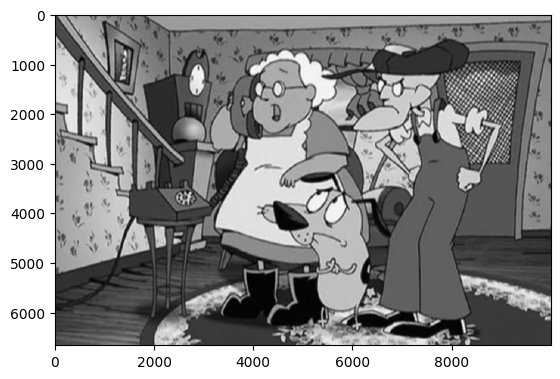

In [ ]:
sx = 10
sy = 10

nova_largura = int(largura * sx)
nova_altura = int(altura * sy)

escalada = np.zeros((nova_altura, nova_largura), dtype=np.uint8)

for x in range(nova_largura):
    for y in range(nova_altura):
        x_original = int(x / sx)
        y_original = int(y / sy)

        escalada[y, x] = img_gray[y_original, x_original]

plt.imshow(escalada, cmap='gray')
plt.imsave('escalada.jpg', escalada, cmap='gray')
plt.show()
#

espelhamento

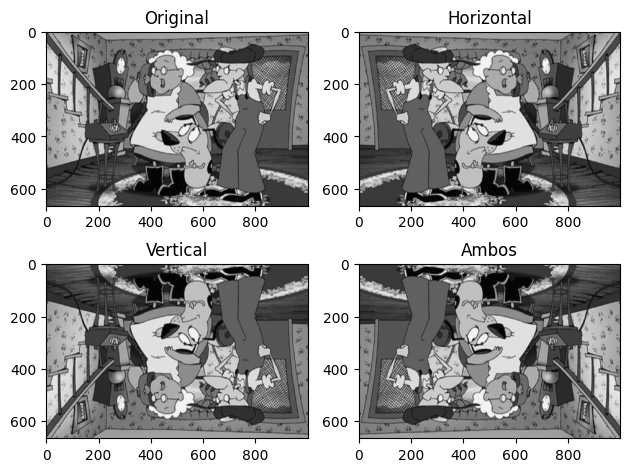

In [ ]:
espelhada_h = np.zeros((altura, largura), dtype=np.uint8)
espelhada_v = np.zeros((altura, largura), dtype=np.uint8)
espelhada_hv = np.zeros((altura, largura), dtype=np.uint8)

for x in range(largura):
    for y in range(altura):
        espelhada_h[y, x] = img_gray[y, largura - x - 1]
        espelhada_v[y, x] = img_gray[altura - y - 1, x]
        espelhada_hv[y, x] = img_gray[altura - y - 1, largura - x - 1]

plt.subplot(2, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original')

plt.subplot(2, 2, 2)
plt.imshow(espelhada_h, cmap='gray')
plt.title('Horizontal')

plt.subplot(2, 2, 3)
plt.imshow(espelhada_v, cmap='gray')
plt.title('Vertical')

plt.subplot(2, 2, 4)
plt.imshow(espelhada_hv, cmap='gray')
plt.title('Ambos')

plt.tight_layout()
plt.show()